In [1]:
import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, linregress
from sklearn.metrics.pairwise import cosine_similarity

import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
## 读取数据
adata = sc.read("cell_cycle(U2OS).h5ad")
adata

AnnData object with n_obs × n_vars = 1138 × 13450
    obs: 'Well_Plate', 'plate', 'phase', 'MeanGreen530', 'MeanRed585', 'fucci_time', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'original_louvain_wp', 'original_louvain', 'Green530', 'Red585', 'louvain'
    var: 'name', 'biotype', 'description', 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'GeneName', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'louvain', 'neighbors', 'pca', 'phase_colors', 'plate_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'matrix', 'spanning', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [3]:
adata.X = adata.layers['matrix'].A
adata.var.index = adata.var['name']

In [4]:
scv.pp.moments(adata, n_pcs=None, n_neighbors=None)

Normalized count data: X, spliced, unspliced.
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


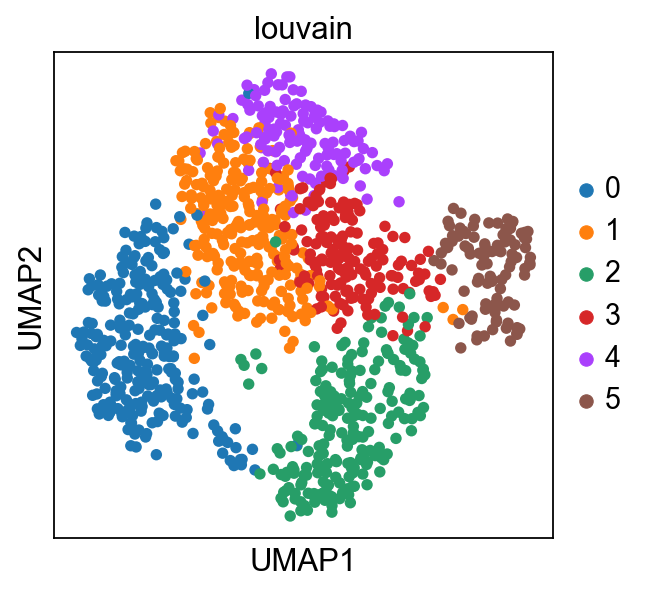

In [5]:
sc.pl.umap(adata, color='louvain',save='_louvain.svg')

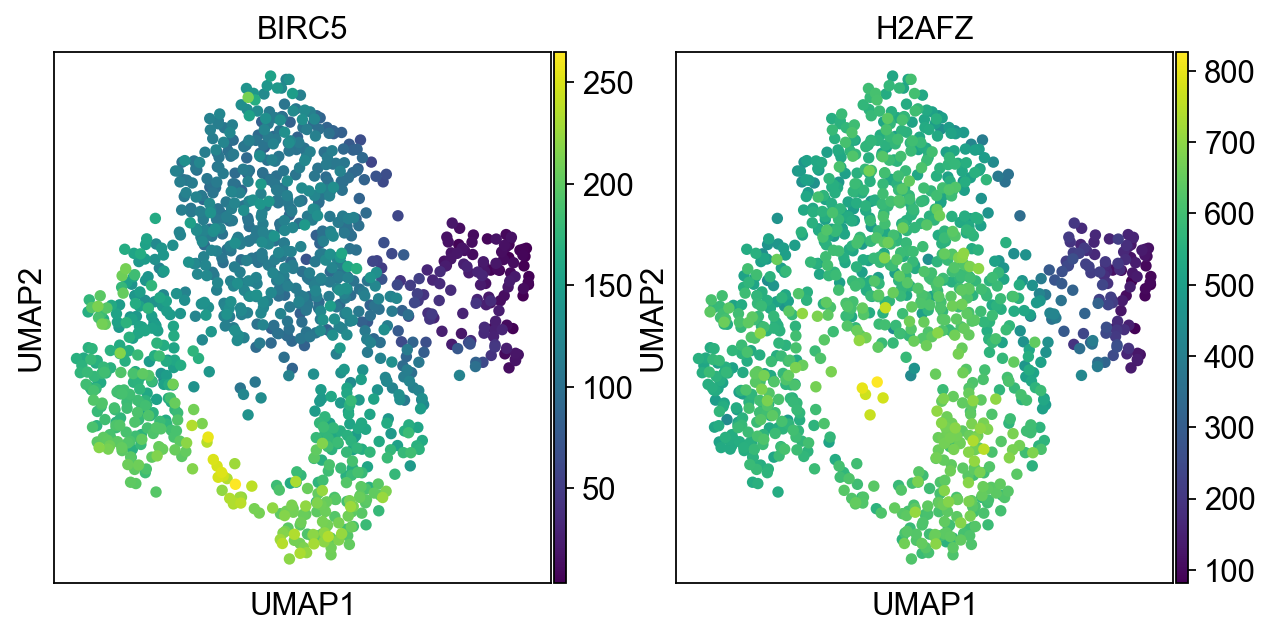

In [6]:
sc.pl.scatter(adata, basis='umap', color=['BIRC5','H2AFZ'], layers='Ms', color_map="viridis",save='_g0up.svg')

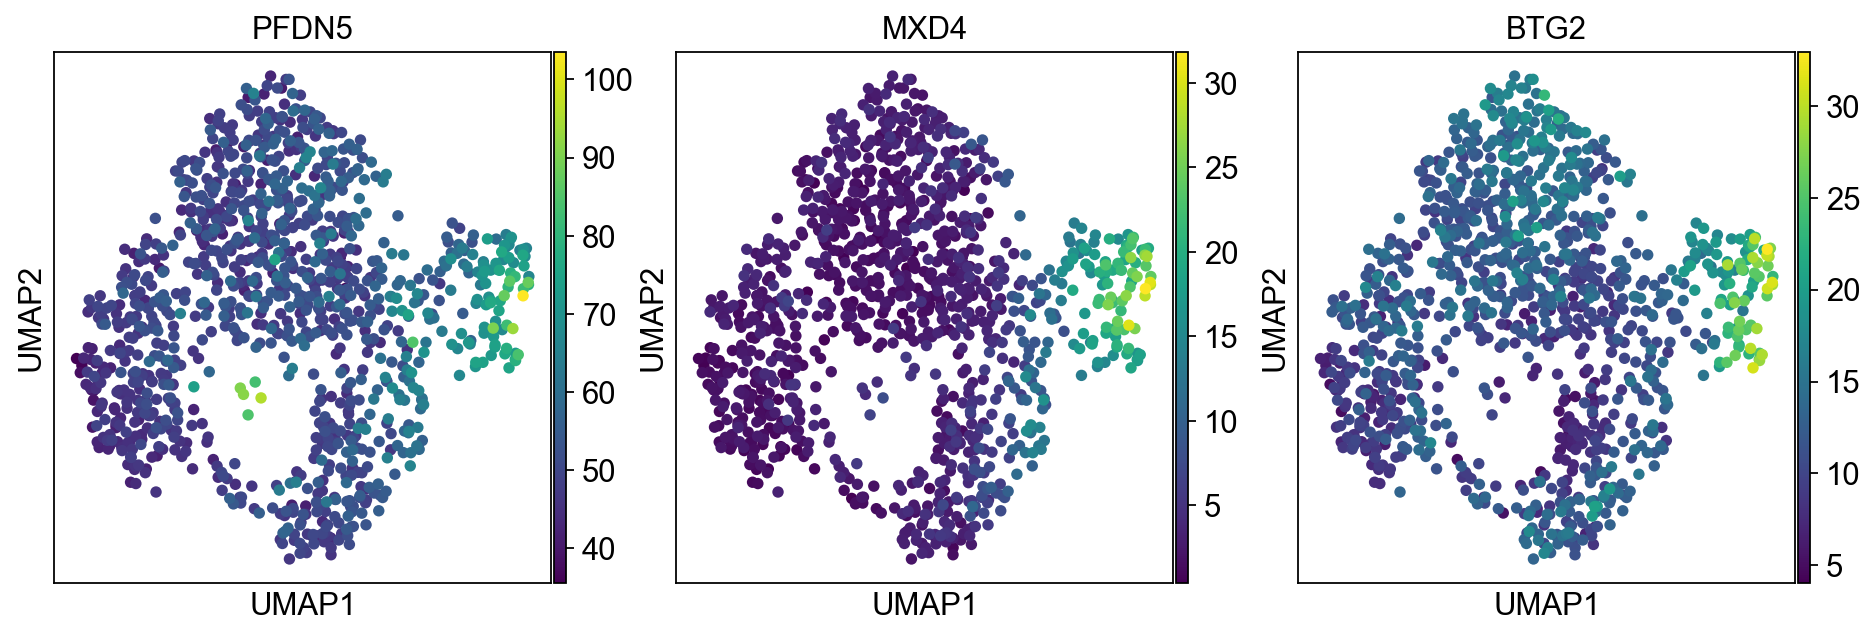

In [7]:
sc.pl.scatter(adata, basis='umap', color=['PFDN5','MXD4','BTG2'], layers='Ms', color_map="viridis",save='_g0down.svg')